# Research of Apartment Sale Listings

This study aims to investigate the pricing of real estate in St. Petersburg and neighboring communities, this will allow the construction of an automated system that can track anomalies and fraudulent activity. 

Two types of data are available for each apartment for sale. The first is entered by the user, the second is obtained automatically on the basis of map data. For example, the distance to the center, airport and other objects - this data is automatically obtained from geoservices. The number of parks and water bodies is also filled in without user input.

## Workplan

1. Study of general information about the data
2. Data preprocessing
    1. Processing missing values
    2. Data types into tables
    3. Eliminating implicit duplicates
3. Adding new columns
4. Exploratory analysis of data
    1. Study of histograms
    2. Studying the speed of apartment sales
    3. What the value of the object depends on
    4. Cost depending on the locality
    5. Cost depending on the distance from the center
5. Overall conclusion

### Learn general information about data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
df = pd.read_csv("./real_estate_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                           --------------  ----- 
 0   total_images	last_price	total_area	first_day_exposition	rooms	ceiling_height	floors_total	living_area	floor	is_apartment	studio	open_plan	kitchen_area	balcony	locality_name	airports_nearest	cityCenters_nearest	parks_around3000	parks_nearest	ponds_around

Based on the `info()` method, we can see that the data contains detailed information about each apartment. This includes photos, locations, furniture, number of floors, etc. Let's try to output the first 10 rows for clarity

In [4]:
display(df.head(10))

,total_images\tlast_price\ttotal_area\tfirst_day_exposition\trooms\tceiling_height\tfloors_total\tliving_area\tfloor\tis_apartment\tstudio\topen_plan\tkitchen_area\tbalcony\tlocality_name\tairports_nearest\tcityCenters_nearest\tparks_around3000\tparks_nearest\tponds_around3000\tponds_nearest\tdays_exposition
0,20\t13000000.0\t108.0\t2019-03-07T00:00:00\t3\...
1,7\t3350000.0\t40.4\t2018-12-04T00:00:00\t1\t\t...
2,10\t5196000.0\t56.0\t2015-08-20T00:00:00\t2\t\...
3,0\t64900000.0\t159.0\t2015-07-24T00:00:00\t3\t...
4,2\t10000000.0\t100.0\t2018-06-19T00:00:00\t2\t...
5,10\t2890000.0\t30.4\t2018-09-10T00:00:00\t1\t\...
6,6\t3700000.0\t37.3\t2017-11-02T00:00:00\t1\t\t...
7,5\t7915000.0\t71.6\t2019-04-18T00:00:00\t2\t\t...
8,20\t2900000.0\t33.16\t2018-05-23T00:00:00\t1\t...
9,18\t5400000.0\t61.0\t2017-02-26T00:00:00\t3\t2...


As you can see, the data is separated by a tab character, so when reading the data you should add the separator `sep=“\t”`.

In [5]:
df = pd.read_csv("./real_estate_data.csv", sep="\t")
display(df.head(5))

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


You can see a certain number of gaps in the data that will need to be processed. For clarity, let's draw a histogram for all data

array([[<Axes: title={'center': 'total_images'}>,
        <Axes: title={'center': 'last_price'}>,
        <Axes: title={'center': 'total_area'}>,
        <Axes: title={'center': 'rooms'}>],
       [<Axes: title={'center': 'ceiling_height'}>,
        <Axes: title={'center': 'floors_total'}>,
        <Axes: title={'center': 'living_area'}>,
        <Axes: title={'center': 'floor'}>],
       [<Axes: title={'center': 'kitchen_area'}>,
        <Axes: title={'center': 'balcony'}>,
        <Axes: title={'center': 'airports_nearest'}>,
        <Axes: title={'center': 'cityCenters_nearest'}>],
       [<Axes: title={'center': 'parks_around3000'}>,
        <Axes: title={'center': 'parks_nearest'}>,
        <Axes: title={'center': 'ponds_around3000'}>,
        <Axes: title={'center': 'ponds_nearest'}>],
       [<Axes: title={'center': 'days_exposition'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

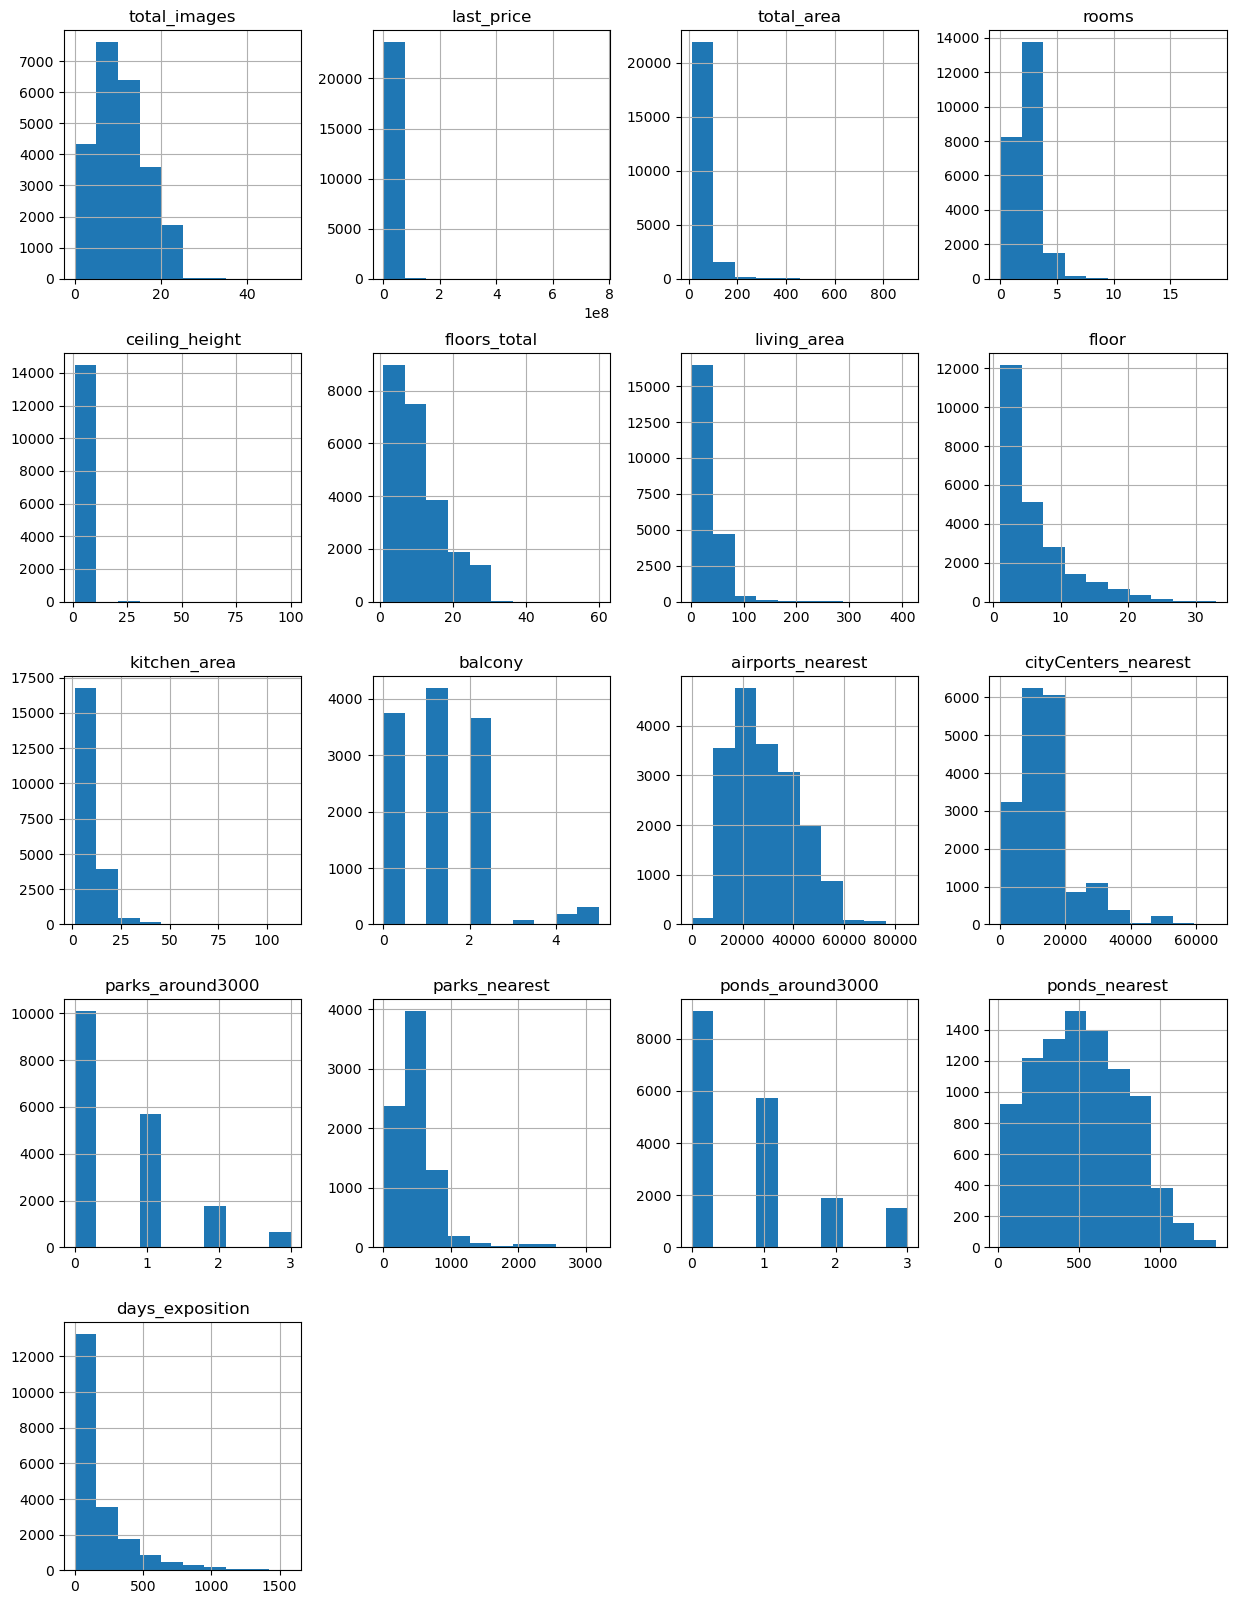

In [6]:
df.hist(figsize=(15, 20))

Some of the graphs can already show a Poisson distribution or a normal distribution. In the rest of them, we will need to adjust the number of baskets or make other adjustments. It remains to check for duplicates

In [7]:
display(df.duplicated().sum())

0

As you can see there are no duplicates

### Data preprocessing

#### Handling missing values

In order to detect missing values we apply the `.value_counts()` method, which returns the unique values in the column along with the number of those unique values.

In [8]:
df.isna().sum().sort_values(ascending=False)

is_apartment            20924
parks_nearest           15620
ponds_nearest           14589
balcony                 11519
ceiling_height           9195
airports_nearest         5542
cityCenters_nearest      5519
ponds_around3000         5518
parks_around3000         5518
days_exposition          3181
kitchen_area             2278
living_area              1903
floors_total               86
locality_name              49
total_images                0
last_price                  0
studio                      0
floor                       0
rooms                       0
first_day_exposition        0
total_area                  0
open_plan                   0
dtype: int64

Several omissions were found in the following columns:
- `ceiling_height`: ceiling height
- `floors_total`: total number of floors
- `living_area`: living area
- `is_apartment`: whether the dwelling is an apartment
- `kitchen_area`: kitchen area
- `balcony`: number of balconies
- `locality_name`: name of the locality
- `airports_nearest`: distance to the nearest airport
- `cityCenters_nearest`: distance to the city center
- `parks_around3000`: number of parks within a 3 km radius
- `parks_nearest`: distance to the nearest park (m)
- `ponds_around3000`: number of water bodies within 3 km radius
- `ponds_nearest`: distance to the nearest body of water (m)
- `days_exposition`: how many days the ad has been posted (from posting to removal)

Now let's look at the fraction of these omissions by column to decide whether to remove them

In [9]:
df.isna().mean().sort_values(ascending=False) * 100

is_apartment            88.290645
parks_nearest           65.909954
ponds_nearest           61.559559
balcony                 48.605426
ceiling_height          38.799105
airports_nearest        23.384953
cityCenters_nearest     23.287902
ponds_around3000        23.283683
parks_around3000        23.283683
days_exposition         13.422507
kitchen_area             9.612220
living_area              8.029875
floors_total             0.362885
locality_name            0.206760
total_images             0.000000
last_price               0.000000
studio                   0.000000
floor                    0.000000
rooms                    0.000000
first_day_exposition     0.000000
total_area               0.000000
open_plan                0.000000
dtype: float64

The columns `is_apartment`, `parks_nearest`, `ponds_nearest`, `balcony`, `ceiling_height` should not be deleted because they occupy a rather large proportion of the total number of values, such omissions should be handled in a certain way. For example, omitted parks and ponds can be replaced with zeros, because most likely the omissions implied their absence in the vicinity.

##### Filling gaps in ceiling height

In [10]:
df[df['ceiling_height'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
11,9,3300000.0,44.00,2018-08-27T00:00:00,2,NaN,5.0,31.00,4,False,...,6.00,1.0,Ломоносов,48252.0,51677.0,0.0,NaN,0.0,NaN,7.0
12,10,3890000.0,54.00,2016-06-30T00:00:00,2,NaN,5.0,30.00,5,NaN,...,9.00,0.0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,90.0
14,1,4400000.0,36.00,2016-06-23T00:00:00,1,NaN,6.0,17.00,1,NaN,...,8.00,0.0,Пушкин,20782.0,30759.0,0.0,NaN,1.0,96.0,203.0


Most likely these omissions are due to the fact that the ceiling height is unknown (because there are several floors) or it is an error of the collection system. Such values can be filled with the average ceiling height from the table.

In [11]:
avg_ceiling_height = math.ceil(df['ceiling_height'].mean() * 100) / 100
df['ceiling_height'] = df['ceiling_height'].fillna(avg_ceiling_height)
display(df['ceiling_height'].isna().sum())

0

##### Completion of passes in total number of floors

In [12]:
df[df['floors_total'].isna()]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
186,12,11640000.0,65.2,2018-10-02T00:00:00,2,2.78,NaN,30.80,4,NaN,...,12.00,NaN,Санкт-Петербург,39197.0,12373.0,1.0,123.0,0.0,NaN,49.0
237,4,2438033.0,28.1,2016-11-23T00:00:00,1,2.78,NaN,20.75,1,NaN,...,NaN,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,251.0
457,4,9788348.0,70.8,2015-08-01T00:00:00,2,2.78,NaN,38.40,12,NaN,...,10.63,0.0,Санкт-Петербург,37364.0,8322.0,2.0,309.0,2.0,706.0,727.0
671,4,6051191.0,93.6,2017-04-06T00:00:00,3,2.78,NaN,47.10,8,NaN,...,16.80,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,123.0
1757,5,3600000.0,39.0,2017-04-22T00:00:00,1,2.78,NaN,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,22735.0,11618.0,1.0,835.0,1.0,652.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22542,5,8500000.0,63.5,2017-05-24T00:00:00,2,2.80,NaN,NaN,3,NaN,...,NaN,NaN,Санкт-Петербург,51340.0,15363.0,0.0,NaN,1.0,853.0,512.0
22656,4,4574160.0,64.5,2017-04-02T00:00:00,2,2.78,NaN,31.70,20,NaN,...,14.40,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,127.0
22808,0,14569263.0,110.4,2016-11-20T00:00:00,3,2.78,NaN,45.38,6,NaN,...,23.42,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,260.0
23590,0,21187872.0,123.3,2017-04-25T00:00:00,3,2.78,NaN,50.40,18,NaN,...,23.60,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,104.0


You may notice that all apartments with `floors_total` has the value NaN. It is more appropriate to delete such apartments

In [13]:
df = df.dropna(subset=['floors_total'])
df['floors_total'].isna().sum()

0

##### Filling gaps in the `is_apartment` column

In [14]:
df[df['is_apartment'].isna() & df['total_area'] < 200]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.78,11.0,18.6,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.78,5.0,34.3,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,2.78,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,2.78,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,2.78,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


##### Filling out gaps in the living area

In [15]:
df[df['living_area'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.78,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
7,5,7915000.0,71.6,2019-04-18T00:00:00,2,2.78,24.0,NaN,22,NaN,...,18.9,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
30,12,2200000.0,32.8,2018-02-19T00:00:00,1,2.78,9.0,NaN,2,NaN,...,NaN,NaN,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.8,2017-10-28T00:00:00,2,2.50,5.0,NaN,1,NaN,...,NaN,NaN,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,NaN,3,NaN,...,NaN,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
59,15,6300000.0,46.5,2017-03-06T00:00:00,1,2.78,13.0,NaN,13,NaN,...,NaN,NaN,Санкт-Петербург,11125.0,14501.0,0.0,NaN,0.0,NaN,336.0
60,3,2740000.0,35.0,2018-01-01T00:00:00,1,2.78,12.0,NaN,8,NaN,...,NaN,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
81,9,10949000.0,68.0,2018-12-27T00:00:00,1,2.78,10.0,NaN,6,NaN,...,NaN,NaN,Санкт-Петербург,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,3,4500000.0,80.5,2018-01-15T00:00:00,3,2.78,25.0,NaN,16,NaN,...,NaN,NaN,посёлок Шушары,12430.0,18217.0,0.0,NaN,0.0,NaN,60.0
116,18,10999000.0,97.2,2017-11-13T00:00:00,3,2.50,16.0,NaN,16,NaN,...,18.3,5.0,Санкт-Петербург,19426.0,21138.0,0.0,NaN,2.0,390.0,394.0


Missing area has no regularity. Most likely it is a trivial error in data collection, omissions should be replaced by average values for the whole dataset

In [16]:
avg_living_area = math.ceil(df['living_area'].mean() * 100) / 100
df['living_area'] = df['living_area'].fillna(avg_living_area)
display(df['living_area'].isna().sum())

0

##### Filling out passes in the balconies column

In [17]:
df[df['balcony'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.78,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.78,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
10,5,5050000.0,39.60,2017-11-16T00:00:00,1,2.67,12.0,20.30,3,NaN,...,8.50,NaN,Санкт-Петербург,38357.0,13878.0,1.0,310.0,2.0,553.0,137.0
16,11,6700000.0,82.00,2017-11-23T00:00:00,3,3.05,5.0,55.60,1,NaN,...,9.00,NaN,Санкт-Петербург,22108.0,10698.0,3.0,420.0,0.0,NaN,397.0
19,16,14200000.0,121.00,2019-01-09T00:00:00,3,2.75,16.0,76.00,8,NaN,...,12.00,NaN,Санкт-Петербург,38900.0,12843.0,0.0,NaN,0.0,NaN,97.0
23,11,2950000.0,32.00,2016-10-29T00:00:00,1,2.60,9.0,17.70,9,NaN,...,6.10,NaN,Санкт-Петербург,15414.0,14211.0,2.0,517.0,1.0,190.0,615.0
26,6,4050000.0,60.00,2017-04-28T00:00:00,4,2.78,5.0,43.00,4,NaN,...,7.00,NaN,Санкт-Петербург,11580.0,10510.0,0.0,NaN,1.0,95.0,265.0
30,12,2200000.0,32.80,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,NaN,NaN,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0


Most likely balconies were an optional input field and not all people entered data about their balconies because they thought it was pointless due to their absence. It is reasonable to replace these values with 0

In [18]:
df['balcony'] = df['balcony'].fillna(0)
df['balcony'].isna().sum()

0

##### Filling in the gaps in the kitchen area column

In [19]:
df[df['kitchen_area'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.78,14.0,34.47,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
30,12,2200000.0,32.8,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,NaN,0.0,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.8,2017-10-28T00:00:00,2,2.50,5.0,34.47,1,NaN,...,NaN,0.0,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,34.47,3,NaN,...,NaN,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
59,15,6300000.0,46.5,2017-03-06T00:00:00,1,2.78,13.0,34.47,13,NaN,...,NaN,0.0,Санкт-Петербург,11125.0,14501.0,0.0,NaN,0.0,NaN,336.0
60,3,2740000.0,35.0,2018-01-01T00:00:00,1,2.78,12.0,34.47,8,NaN,...,NaN,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
81,9,10949000.0,68.0,2018-12-27T00:00:00,1,2.78,10.0,34.47,6,NaN,...,NaN,0.0,Санкт-Петербург,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,3,4500000.0,80.5,2018-01-15T00:00:00,3,2.78,25.0,34.47,16,NaN,...,NaN,0.0,посёлок Шушары,12430.0,18217.0,0.0,NaN,0.0,NaN,60.0
133,12,3150000.0,31.0,2018-03-23T00:00:00,1,2.78,25.0,34.47,6,NaN,...,NaN,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,78.0
144,1,2450000.0,27.0,2017-03-30T00:00:00,0,2.78,24.0,15.50,2,NaN,...,NaN,2.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,181.0


Most likely, the kitchen area was omitted because either there is no kitchen in the apartment (this is an advertisement for a communal apartment) or this part of the data was not collected for some technical reason. The missing values can be replaced by the average kitchen area

In [20]:
avg_kitchen_area = math.ceil(df['kitchen_area'].mean() * 10) / 10
df['kitchen_area'] = df['kitchen_area'].fillna(avg_kitchen_area)
display(df['kitchen_area'].isna().sum())

0

After filling in the kitchen areas, it is necessary to check that the total area column is equal to the kitchen area + living area.

In [21]:
def kitchen_area_check(row):
    real_total_area = row['total_area']
    living_area = row['living_area']
    kitchen_area = row['kitchen_area']
    tmp_total_area = living_area + kitchen_area
    if tmp_total_area != real_total_area:
        return real_total_area - living_area
    return kitchen_area

df['kitchen_area'] = df.apply(kitchen_area_check, axis=1)

Now let's fill in the blanks in the total area

In [22]:
avg_kitchen_area = math.ceil(df['total_area'].mean() * 10) / 10
df['total_area'] = df['total_area'].fillna(avg_kitchen_area)
display(df['total_area'].isna().sum())

0

In [23]:
def total_area_check(row):
    real_total_area = row['total_area']
    living_area = row['living_area']
    kitchen_area = row['kitchen_area']
    tmp_total_area = living_area + kitchen_area
    if tmp_total_area != real_total_area:
        return tmp_total_area
    return real_total_area

df['total_area'] = df.apply(total_area_check, axis=1)

##### Filling in of passes in the settlement column

In [24]:
df[df['locality_name'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1097,3,8600000.0,81.7,2016-04-15T00:00:00,3,3.55,5.0,50.80,2,NaN,...,30.90,0.0,NaN,23478.0,4258.0,0.0,NaN,0.0,NaN,147.0
2033,6,5398000.0,80.0,2017-05-30T00:00:00,3,2.78,4.0,42.60,2,NaN,...,37.40,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0
2603,20,3351765.0,42.7,2015-09-20T00:00:00,1,2.78,24.0,15.60,3,NaN,...,27.10,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,276.0
2632,2,5130593.0,62.4,2015-10-11T00:00:00,2,2.78,24.0,33.10,21,NaN,...,29.30,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,256.0
3574,10,4200000.0,46.5,2016-05-28T00:00:00,2,2.78,5.0,30.80,5,NaN,...,15.70,0.0,NaN,27419.0,8127.0,0.0,NaN,1.0,603.0,45.0
4151,17,17600000.0,89.5,2014-12-09T00:00:00,2,3.00,8.0,39.62,7,NaN,...,49.88,0.0,NaN,25054.0,3902.0,1.0,485.0,3.0,722.0,869.0
4189,7,9200000.0,80.0,2015-12-10T00:00:00,3,4.00,4.0,52.30,3,False,...,27.70,0.0,NaN,21774.0,3039.0,1.0,690.0,1.0,953.0,223.0
4670,1,5500000.0,83.0,2015-08-14T00:00:00,3,2.78,7.0,34.47,6,NaN,...,48.53,0.0,NaN,26534.0,5382.0,1.0,446.0,1.0,376.0,350.0
5343,19,13540000.0,85.5,2016-01-20T00:00:00,3,2.78,7.0,59.10,5,False,...,26.40,4.0,NaN,10556.0,9538.0,1.0,67.0,0.0,NaN,303.0
5707,7,3700000.0,30.0,2016-04-29T00:00:00,1,2.78,24.0,20.00,23,NaN,...,10.00,0.0,NaN,21460.0,16788.0,0.0,NaN,1.0,170.0,49.0


Since the analysis is conducted exclusively for St. Petersburg, it is hard to say to which locality these data refer. It would be more logical to delete them

In [25]:
df = df.dropna(subset=['locality_name'])
df['locality_name'].isna().sum()

0

##### Filling in gaps in distance columns

In [26]:
df['airports_nearest'].isna().sum()

5524

In [27]:
df['cityCenters_nearest'].isna().sum()

5501

In [28]:
df[df['airports_nearest'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.78,12.0,14.40,5,NaN,...,16.00,0.0,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.78,27.0,15.43,26,NaN,...,17.73,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
12,10,3890000.0,54.00,2016-06-30T00:00:00,2,2.78,5.0,30.00,5,NaN,...,24.00,0.0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,90.0
22,20,5000000.0,58.00,2017-04-24T00:00:00,2,2.75,25.0,30.00,15,NaN,...,28.00,2.0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,60.0
30,12,2200000.0,32.80,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,-1.67,0.0,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.80,2017-10-28T00:00:00,2,2.50,5.0,34.47,1,NaN,...,11.33,0.0,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
38,10,3150000.0,40.00,2018-03-29T00:00:00,1,2.75,18.0,16.30,9,NaN,...,23.70,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,103.0
47,17,3600000.0,56.10,2018-10-18T00:00:00,3,2.78,4.0,42.50,3,NaN,...,13.60,1.0,Гатчина,NaN,NaN,NaN,NaN,NaN,NaN,179.0
60,3,2740000.0,35.00,2018-01-01T00:00:00,1,2.78,12.0,34.47,8,NaN,...,0.53,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
62,0,4800000.0,78.60,2017-09-17T00:00:00,3,2.80,9.0,48.80,5,NaN,...,29.80,2.0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,5.0


There is an impressive amount of missing data by airport. Perhaps apartments that are too far from the main airport (Pulkovo) are shown in this way. For example, Sertolovo is so far from the airport that the filler/system did not consider it necessary to record the distance. It can also be noticed that almost all data with missing distance to the airport have omissions in almost all columns with distance to anything. In such apartments almost half of the necessary data is missing and it will be very hard to make any logical conclusions. Delete :)

In [29]:
df = df.dropna(subset=['airports_nearest', 'cityCenters_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest'])
df['airports_nearest'].isna().sum()

0

##### Filling in the passes in the accommodation columns by day

In [30]:
df[df['days_exposition'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,57.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,34.47,3,NaN,...,5.53,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
71,20,4850000.0,57.5,2019-03-27T00:00:00,3,2.50,9.0,39.00,8,NaN,...,18.50,0.0,Санкт-Петербург,33623.0,12267.0,1.0,334.0,1.0,333.0,NaN
114,5,4000000.0,21.4,2019-02-07T00:00:00,1,2.90,8.0,8.30,7,NaN,...,13.10,0.0,Санкт-Петербург,27089.0,5791.0,2.0,488.0,1.0,286.0,NaN
126,10,4050000.0,51.0,2019-04-23T00:00:00,2,2.78,5.0,30.50,1,NaN,...,20.50,0.0,Пушкин,17974.0,32546.0,1.0,15.0,1.0,659.0,NaN
206,16,5080000.0,31.3,2019-04-23T00:00:00,1,2.50,7.0,16.00,4,False,...,15.30,1.0,Санкт-Петербург,27753.0,6692.0,1.0,860.0,1.0,694.0,NaN
207,11,9000000.0,72.6,2018-09-08T00:00:00,2,2.90,5.0,43.20,4,NaN,...,29.40,0.0,Санкт-Петербург,22794.0,1645.0,2.0,276.0,3.0,485.0,NaN
233,17,19800000.0,118.0,2017-12-15T00:00:00,3,2.80,25.0,62.00,3,NaN,...,56.00,0.0,Санкт-Петербург,36827.0,12348.0,1.0,485.0,1.0,474.0,NaN
270,13,3700000.0,34.0,2019-03-18T00:00:00,1,2.60,10.0,18.00,8,NaN,...,16.00,1.0,Санкт-Петербург,32831.0,13995.0,1.0,104.0,1.0,393.0,NaN
278,19,6000000.0,56.7,2019-03-11T00:00:00,2,3.20,5.0,34.10,5,NaN,...,22.60,0.0,Санкт-Петербург,22800.0,9274.0,1.0,77.0,1.0,542.0,NaN


Most likely these apartments are not for sale because they have not been sold yet. In this case they should not be deleted

#### Type of data in the table

In [31]:
df.dtypes

total_images              int64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
cityCenters_nearest     float64
parks_around3000        float64
parks_nearest           float64
ponds_around3000        float64
ponds_nearest           float64
days_exposition         float64
dtype: object

In [32]:
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,57.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,2.78,5.0,34.30,4,NaN,...,21.70,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.78,14.0,34.47,9,NaN,...,124.53,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,68.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
10,5,5050000.0,39.6,2017-11-16T00:00:00,1,2.67,12.0,20.30,3,NaN,...,19.30,0.0,Санкт-Петербург,38357.0,13878.0,1.0,310.0,2.0,553.0,137.0


The pattern where values that cannot be real are of type `float64` immediately catches our eye. Such values should be changed to `int64` type. We are talking about the following columns:
- `floors_total`.
- `balcony`
- `parks_around3000`
- `ponds_around3000`

First, let's make sure that the columns do not have values with a real part

In [33]:
def check_float(df, column_name):
    return df[df[column_name] % 1 != 0][column_name].sum()

for column in ['floors_total', 'balcony', 'parks_around3000', 'ponds_around3000']:
    if check_float(df, column) > 0:
        display(f'{column} has float')
    else:
        display(f'{column} is OK')

'floors_total is OK'

'balcony is OK'

'parks_around3000 is OK'

'ponds_around3000 is OK'

Now let's replace the types of these columns

In [34]:
df['floors_total'] = df['floors_total'].astype(int)
df['balcony'] = df['balcony'].astype(int)
df['parks_around3000'] = df['parks_around3000'].astype(int)
df['ponds_around3000'] = df['ponds_around3000'].astype(int)

Now checking the non-obvious columns:
- `airports_nearest`.
- `cityCenters_nearest`.
- `parks_nearest`
- `ponds_nearest

In [35]:
for column in ['last_price', 'airports_nearest', 'cityCenters_nearest', 'parks_nearest', 'ponds_nearest']:
    if check_float(df, column) > 0:
        display(f'{column} has float')
    else:
        display(f'{column} is OK')

'last_price is OK'

'airports_nearest is OK'

'cityCenters_nearest is OK'

'parks_nearest is OK'

'ponds_nearest is OK'

As we can see, all values in the distances have integers, so it is more logical to replace them with the `int` type

In [36]:
df['last_price'] = df['last_price'].astype(int)
df['airports_nearest'] = df['airports_nearest'].astype(int)
df['cityCenters_nearest'] = df['cityCenters_nearest'].astype(int)
df['parks_nearest'] = df['parks_nearest'].astype(int)
df['ponds_nearest'] = df['ponds_nearest'].astype(int)

Also, some columns can be converted from `object` to something else more appropriate. `locality_name` can be made into `str`, and `is_apartment` into `bool`.

In [37]:
df['locality_name'] = df['locality_name'].astype("string")
df['is_apartment'] = df['is_apartment'].astype(bool)

Let's take a look at the new types

In [38]:
df.dtypes

total_images                     int64
last_price                       int64
total_area                     float64
first_day_exposition            object
rooms                            int64
ceiling_height                 float64
floors_total                     int64
living_area                    float64
floor                            int64
is_apartment                      bool
studio                            bool
open_plan                         bool
kitchen_area                   float64
balcony                          int64
locality_name           string[python]
airports_nearest                 int64
cityCenters_nearest              int64
parks_around3000                 int64
parks_nearest                    int64
ponds_around3000                 int64
ponds_nearest                    int64
days_exposition                float64
dtype: object

#### Eliminating Implicit Duplicates

In [39]:
df['locality_name'].unique()

<StringArray>
[  'Санкт-Петербург',          'Петергоф',            'Пушкин',
         'Кронштадт',           'Колпино',          'Павловск',
        'Сестрорецк',       'Зеленогорск',         'Ломоносов',
 'посёлок Парголово',      'Красное Село',  'посёлок Стрельна']
Length: 12, dtype: string

No implicit duplicates were found in the titles

### Add new columns

Let's add columns with the following parameters:
- price of one square meter (you need to divide the cost of the object by its total area, and then round up to two decimal places);
- day of the week when the ad was published (0 - Monday, 1 - Tuesday and so on);
- month of the ad's publication
- year of announcement publication;
- type of apartment floor (values - “first”, “last”, “other”);
- distance to the city center in kilometers (convert from m to km and round up to the nearest integer value).

In [40]:
from datetime import datetime

def process_day(row):
    date = row['first_day_exposition']
    date_obj = datetime.fromisoformat(date.split('T')[0])
    return date_obj.weekday()

def process_month(row):
    date = row['first_day_exposition']
    return date.split('-')[1]

def process_year(row):
    date = row['first_day_exposition']
    return date.split('-')[0]
    

def assign_floot_type(row):
    floor = row['floor']
    floors_total = row['floors_total']
    if floor == 1:
        return 'первый'
    elif floor == floors_total:
        return 'последний'
    return 'другой'

df['price_per_sqm'] = (df['last_price'] / df['total_area']).round(2)
df['day_of_the_week'] = df.apply(process_day, axis=1)
df['month_exposition'] = df.apply(process_month, axis=1).astype(int)
df['year_exposition'] = df.apply(process_year, axis=1).astype(int)
df['floor_type'] = df.apply(assign_floot_type, axis=1)
df['cityCenters_nearest_km'] = round(df['cityCenters_nearest'] / 1000)

In [41]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_sqm,day_of_the_week,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
0,20,13000000,108.0,2019-03-07T00:00:00,3,2.70,16,51.00,8,True,...,482,2,755,NaN,120370.37,3,3,2019,другой,16.0
2,10,5196000,56.0,2015-08-20T00:00:00,2,2.78,5,34.30,4,True,...,90,2,574,558.0,92785.71,3,8,2015,другой,14.0
3,0,64900000,159.0,2015-07-24T00:00:00,3,2.78,14,34.47,9,True,...,84,3,234,424.0,408176.10,4,7,2015,другой,7.0
4,2,10000000,100.0,2018-06-19T00:00:00,2,3.03,14,32.00,13,True,...,112,1,48,121.0,100000.00,1,6,2018,другой,8.0
10,5,5050000,39.6,2017-11-16T00:00:00,1,2.67,12,20.30,3,True,...,310,2,553,137.0,127525.25,3,11,2017,другой,14.0


### Exploratory data analysis

#### Let's study histograms for some numerical parameters

Let's start by plotting a histogram for the total area

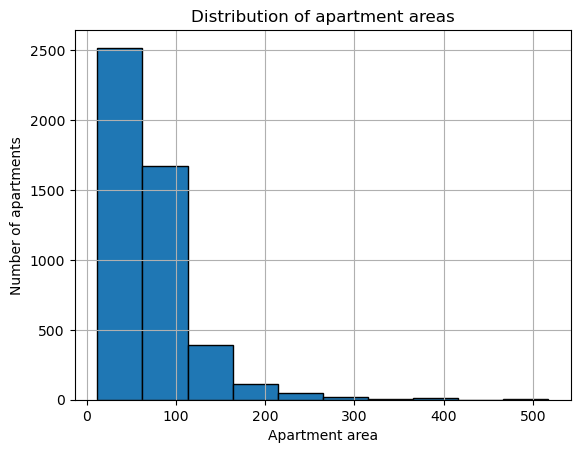

In [42]:
plt.hist(df['total_area'], linewidth=1, edgecolor='black')
plt.xlabel('Apartment area')
plt.ylabel('Number of apartments')
plt.title('Distribution of apartment areas')
plt.grid(True)
plt.show()

The histogram shows that most of the apartments are less than 100 sq/m

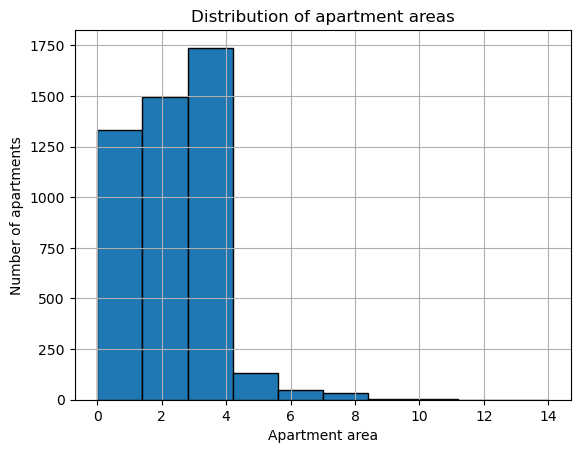

In [43]:
plt.hist(df['rooms'], linewidth=1, edgecolor='black')
plt.xlabel('Apartment area')
plt.ylabel('Number of apartments')
plt.title('Distribution of apartment areas')
plt.grid(True)
plt.show()

Most of the apartments have up to 4 rooms

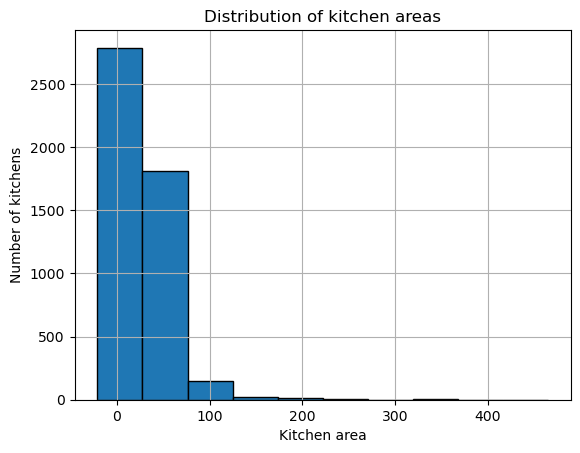

In [44]:
plt.hist(df['kitchen_area'], linewidth=1, edgecolor='black')
plt.xlabel('Kitchen area')
plt.ylabel('Number of kitchens')
plt.title('Distribution of kitchen areas')
plt.grid(True)
plt.show()

The kitchen area is usually no larger than 10 to 20 square feet

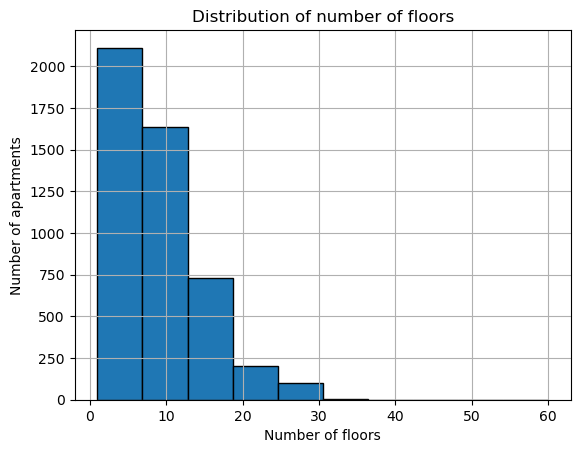

In [45]:
plt.hist(df['floors_total'], linewidth=1, edgecolor='black')
plt.xlabel('Number of floors')
plt.ylabel('Number of apartments')
plt.title('Distribution of number of floors')
plt.grid(True)
plt.show()

By comparing the graphs of total area, living area, kitchen area, number of rooms and number of floors, you can see that they have roughly similar distributions, which is logical. The larger the total area of the property, the larger the living area, kitchen area and number of rooms. 

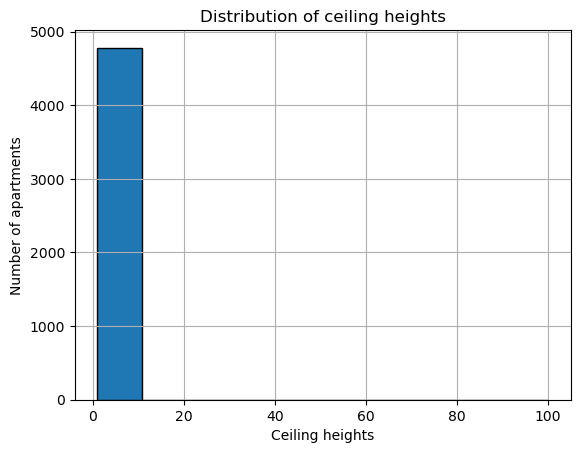

In [46]:
plt.hist(df['ceiling_height'], linewidth=1, edgecolor='black')
plt.xlabel('Ceiling heights')
plt.ylabel('Number of apartments')
plt.title('Distribution of ceiling heights')
plt.grid(True)
plt.show()

The histogram shows that the column contains anomalous values of ceiling heights that need to be treated

In [47]:
df.query('ceiling_height > 5')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_sqm,day_of_the_week,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
464,15,66571000,280.3,2015-06-11T00:00:00,6,5.2,8,159.50,7,True,...,187,1,616,578.0,237499.11,3,6,2015,другой,7.0
1388,20,59800000,399.0,2015-01-21T00:00:00,5,5.6,6,34.47,6,True,...,149,2,577,719.0,149874.69,2,1,2015,последний,7.0
4643,0,4300000,45.0,2018-02-01T00:00:00,2,25.0,9,30.00,2,True,...,658,1,331,181.0,95555.56,3,2,2018,другой,13.0
5076,0,3850000,30.5,2018-10-03T00:00:00,1,24.0,5,19.50,1,True,...,397,1,578,7.0,126229.51,2,10,2018,первый,8.0
6246,6,3300000,44.4,2019-03-25T00:00:00,2,25.0,5,31.30,5,True,...,417,2,73,NaN,74324.32,0,3,2019,последний,51.0
12628,14,3900000,50.0,2018-03-29T00:00:00,1,5.3,5,34.47,5,True,...,505,1,92,8.0,78000.00,3,3,2018,последний,4.0
20264,17,119000000,187.6,2017-07-10T00:00:00,4,6.0,7,147.00,7,True,...,484,1,305,259.0,634328.36,0,7,2017,последний,6.0
21227,0,8200000,71.0,2017-07-21T00:00:00,0,5.8,5,68.00,5,True,...,295,3,366,30.0,115492.96,4,7,2017,последний,1.0
22309,20,5300000,45.0,2017-09-30T00:00:00,1,10.3,16,15.50,15,True,...,440,2,450,136.0,117777.78,5,9,2017,другой,12.0
22869,0,15000000,25.0,2018-07-25T00:00:00,1,100.0,5,14.00,5,True,...,223,3,30,19.0,600000.00,2,7,2018,последний,8.0


In the first case, most likely meant the height of 2.4 meters, but the second case is not clear, because with an area of 25 sq / m and a price of 15_000_000 hard to imagine such a property, so it is more logical to remove this value

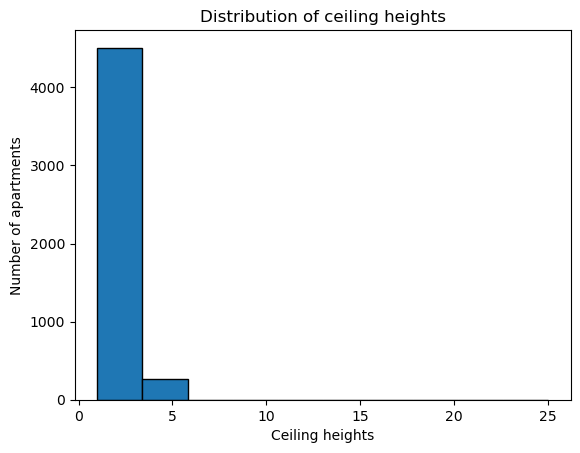

In [48]:
df.loc[df['ceiling_height'] == 24, 'ceiling_height'] = 2.4
df = df.query('ceiling_height != 100.0')
plt.hist(df['ceiling_height'], linewidth=1, edgecolor='black')
plt.xlabel('Ceiling heights')
plt.ylabel('Number of apartments')
plt.title('Distribution of ceiling heights')
plt.show()

Now there are no anomalies, most of the apartments are 2.75m high

<Axes: xlabel='floor_type'>

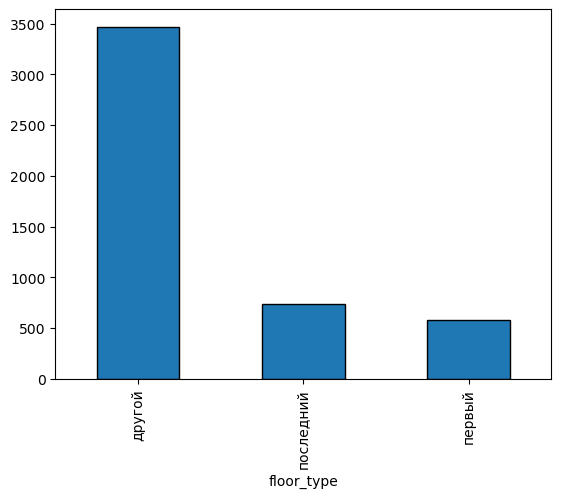

In [49]:
df['floor_type'].value_counts().plot(kind='bar', linewidth=1, edgecolor='black')

Most of the apartments are between the first and last floors, which is logical for high-rise buildings

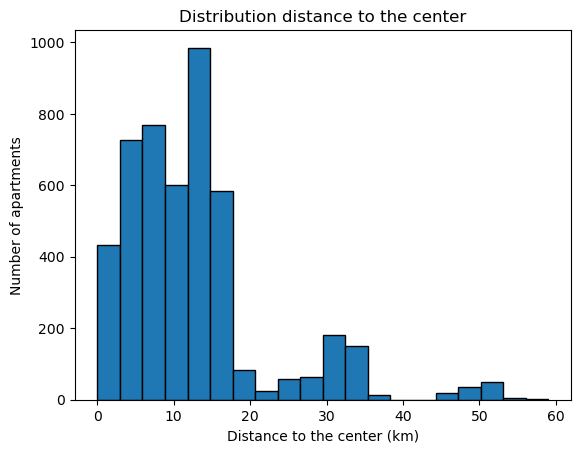

In [50]:
plt.hist(df['cityCenters_nearest_km'], bins=20, linewidth=1, edgecolor='black')
plt.xlabel('Distance to the center (km)')
plt.ylabel('Number of apartments')
plt.title('Distribution distance to the center')
plt.show()

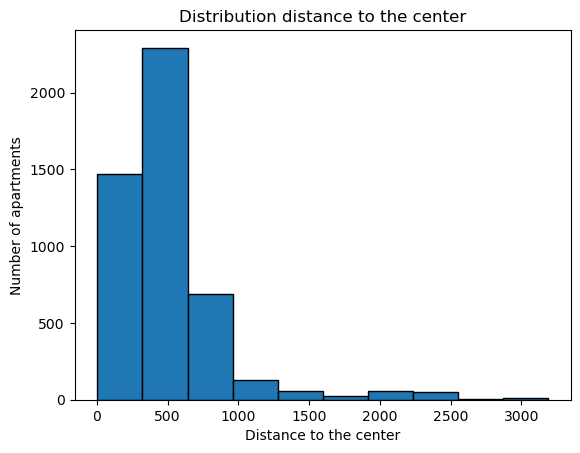

In [51]:
plt.hist(df['parks_nearest'], linewidth=1, edgecolor='black')
plt.xlabel('Distance to the center')
plt.ylabel('Number of apartments')
plt.title('Distribution distance to the center')
plt.show()

The histograms for these two columns are similar. Houses that fall out of the total are likely to be in the countryside and are equidistant from the city center and parks

#### Examine the speed of apartment sales

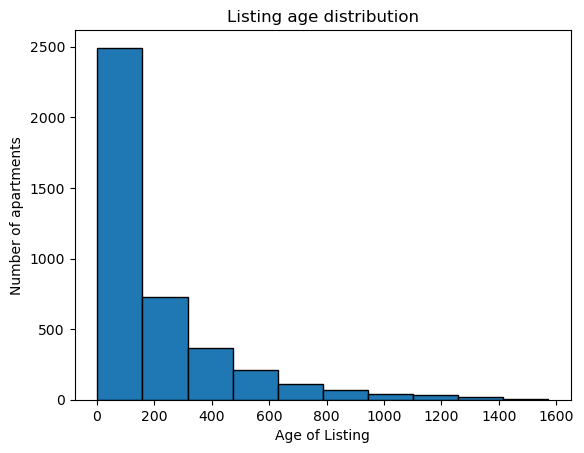

In [52]:
plt.hist(df['days_exposition'], linewidth=1, edgecolor='black')
plt.xlabel('Age of Listing')
plt.ylabel('Number of apartments')
plt.title('Listing age distribution')
plt.show()

The histogram corresponds to the Poisson distribution, which is characteristic of time-related values. Let's look at the arithmetic mean and median values

count    4082.000000
mean      203.546546
std       242.513736
min         1.000000
25%        45.000000
50%       110.500000
75%       264.750000
max      1572.000000
Name: days_exposition, dtype: float64

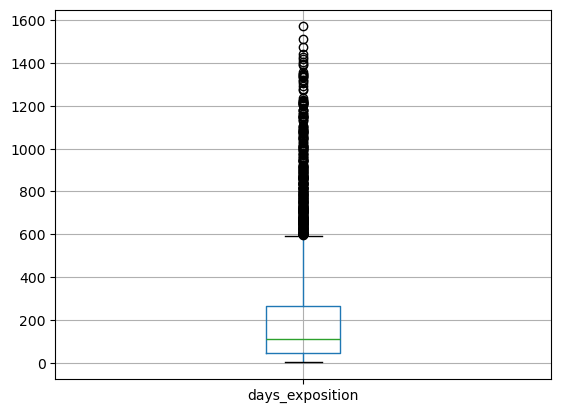

In [53]:
df.boxplot(column=['days_exposition'])
df['days_exposition'].describe()

The histogram corresponds to the Poisson distribution, which is characteristic of time-related values. Let's look at the arithmetic mean and median values

#### Let's determine what the value of the object depends on

To determine if there is a correlation between the price and the different ones, let's look at their correlation coefficients.

In [54]:
for column in ['total_area', 'living_area', 'kitchen_area', 'rooms',
               'day_of_the_week', 'month_exposition', 'year_exposition']:
    print(f'Correlation between "last_price" and "{column}" is {df["last_price"].corr(df[column])}')

Correlation between "last_price" and "total_area" is 0.5920790302217763
Correlation between "last_price" and "living_area" is 0.5095878091714837
Correlation between "last_price" and "kitchen_area" is 0.5336762774806845
Correlation between "last_price" and "rooms" is 0.34559093558979853
Correlation between "last_price" and "day_of_the_week" is 0.015593934297074754
Correlation between "last_price" and "month_exposition" is -0.00510566945440283
Correlation between "last_price" and "year_exposition" is -0.06470445125433007


It can be seen that there is a small dependence related to the size of the kitchen and the number of rooms and a slightly larger dependence related to the living area and total area. The price is not particularly related to dates

To find out what the price depends on, let's analyze the following columns and build a scatter diagram matrix:
- total area;
- living area;
- kitchen area;
- number of rooms;
- type of floor on which the apartment is located (first, last, other);
- date of placement

array([[<Axes: xlabel='total_area', ylabel='total_area'>,
        <Axes: xlabel='living_area', ylabel='total_area'>,
        <Axes: xlabel='kitchen_area', ylabel='total_area'>,
        <Axes: xlabel='rooms', ylabel='total_area'>,
        <Axes: xlabel='floor_type_numeric', ylabel='total_area'>,
        <Axes: xlabel='last_price', ylabel='total_area'>,
        <Axes: xlabel='days_exposition', ylabel='total_area'>,
        <Axes: xlabel='day_of_the_week', ylabel='total_area'>,
        <Axes: xlabel='month_exposition', ylabel='total_area'>,
        <Axes: xlabel='year_exposition', ylabel='total_area'>],
       [<Axes: xlabel='total_area', ylabel='living_area'>,
        <Axes: xlabel='living_area', ylabel='living_area'>,
        <Axes: xlabel='kitchen_area', ylabel='living_area'>,
        <Axes: xlabel='rooms', ylabel='living_area'>,
        <Axes: xlabel='floor_type_numeric', ylabel='living_area'>,
        <Axes: xlabel='last_price', ylabel='living_area'>,
        <Axes: xlabel='days_expo

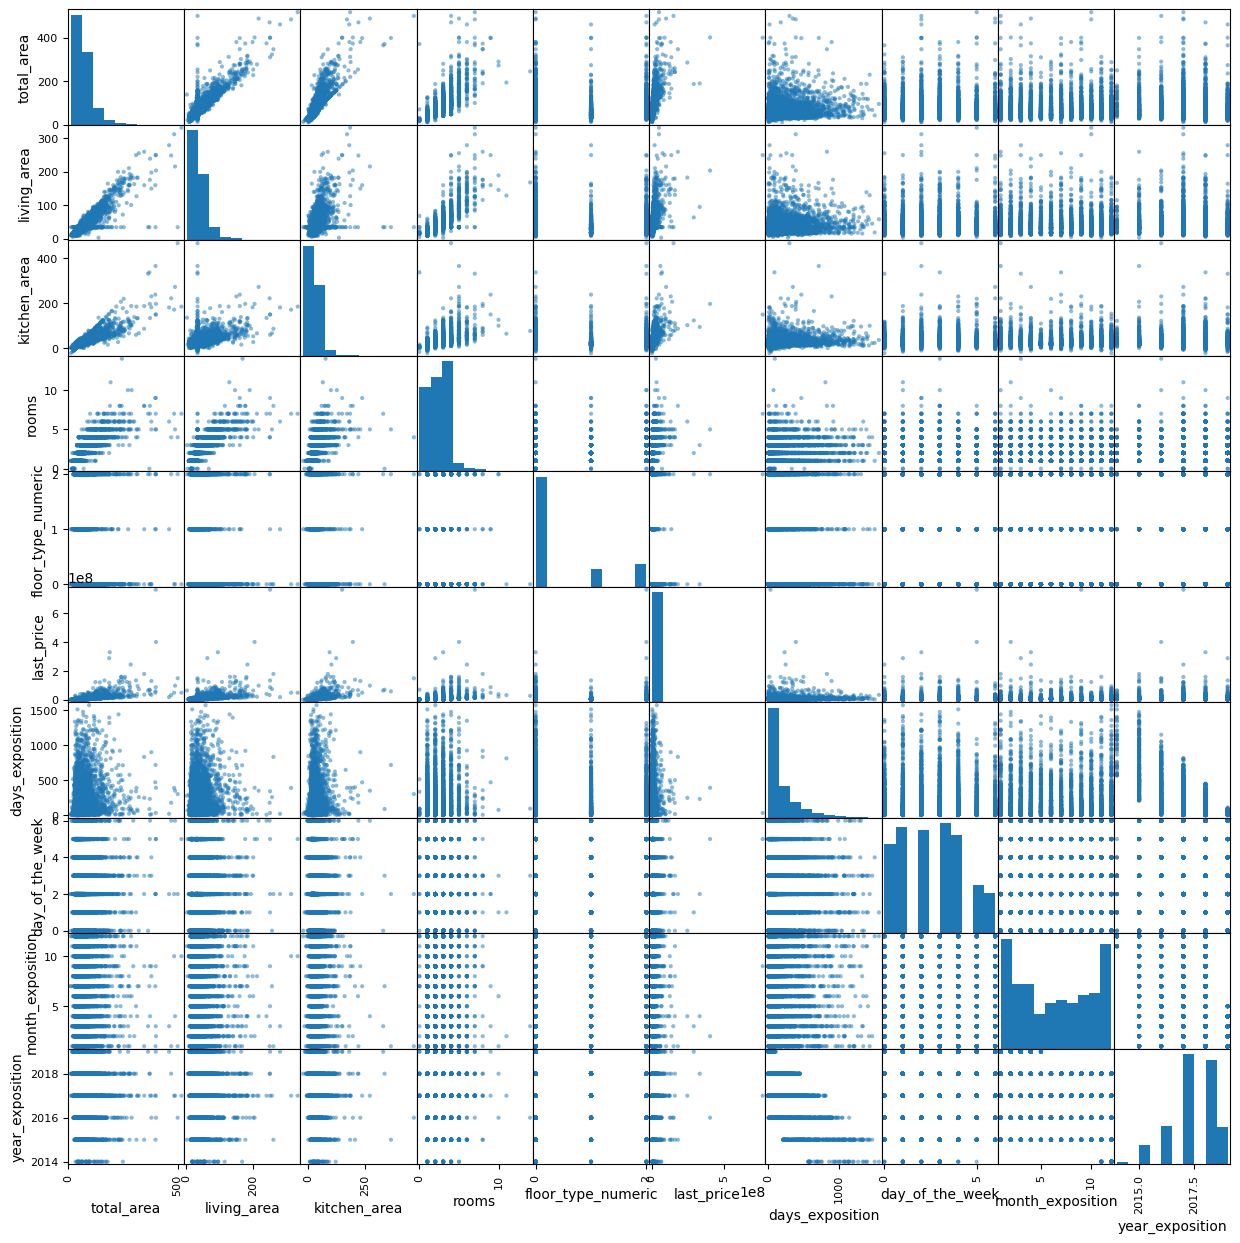

In [55]:
df['floor_type_numeric'] = df['floor_type'].astype('category').cat.codes

relevant_columns = df[['total_area', 'living_area', 'kitchen_area', 'rooms', 'floor_type_numeric', 'last_price', 'days_exposition', 'day_of_the_week', 'month_exposition', 'year_exposition']]

pd.plotting.scatter_matrix(relevant_columns, figsize=(15, 15))

You can see that the total floor area, kitchen area and living area affect the price of a property. The relationship is direct - a larger area usually leads to a higher price. The same applies to the number of rooms. Apartments located on the first floor tend to have a lower price, while those that are relatively new tend to have a slightly higher price. The day of the week and month do not have much effect on the price, but later years tend to have slightly higher prices.

#### Determine cost by locality

In [56]:
pivot = df.pivot_table(index = 'locality_name', values = 'price_per_sqm', aggfunc = ['count', 'mean'])
pivot.columns = ['count', 'price_per_sqm']
(
    pivot.sort_values(by = 'count', ascending = False).head(10)
    .sort_values(by='price_per_sqm', ascending = False)
)

,count,price_per_sqm
locality_name,,
Санкт-Петербург,4228,128739.720220
Зеленогорск,16,109891.073125
Сестрорецк,72,108831.614583
Пушкин,133,107265.692782
Павловск,24,90949.239583
посёлок Стрельна,17,88558.942353
Петергоф,111,86604.563063
Кронштадт,81,79568.634938
Колпино,68,77017.248235


As you can see, the highest price in St. Petersburg, and the lowest in Lomonosov. Most likely, the prices in Lomonosov can be explained by remoteness from most price-determining locations

#### Let's determine the cost depending on the distance from the center

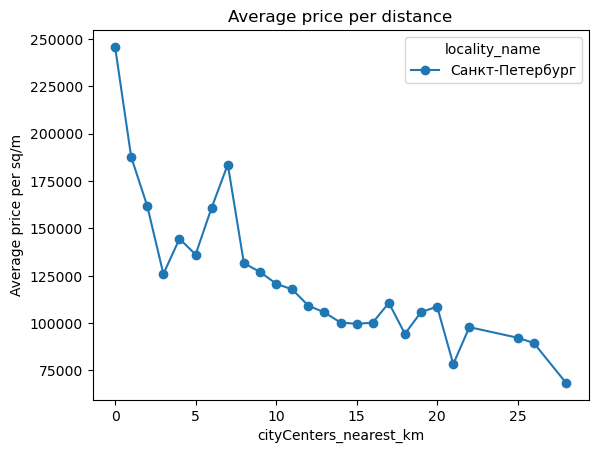

In [57]:
pivot_table = (
    df[df['locality_name'] == 'Санкт-Петербург']
    .pivot_table(index='locality_name', values='price_per_sqm', columns='cityCenters_nearest_km', aggfunc='mean')
)
sorted_pivot_table = pivot_table.sort_values(by=pivot_table.columns[0], ascending=False)
sorted_pivot_table.T.plot(kind='line', marker='o')
plt.ylabel('Average price per sq/m')
plt.title('Average price per distance')
plt.show()

As you can see the distance from the center also affects the price of the property. The farther from the center, the cheaper

### Conclusion

After a detailed analysis we can say that the price of an apartment is influenced by several factors. The total and living area of the apartment affects most of all, slightly less the kitchen area and the number of rooms. Day of the week, month do not play a role, but recently placed apartments, as well as later years of placement tend to have slightly higher prices. Apartments located on the first floor are sold cheaper than apartments on other floors. Distance to the Airport and the Center is also important. The closer, the more expensive. The same is true for the location of the city, its proximity to key price points is important. St. Petersburg itself has the highest real estate prices while Lomonosov has the lowest. St. Petersburg also leads in the number of listings, while Lomonosov has the least.